In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [17]:
combined = pd.read_csv("../finaldata/combined_events.csv")
combined.columns

combined = combined.drop(columns=['DATE','Attendance_Ratio','AWARDED'])


## Attempt to One-Hot Encode all categorical variables

In [18]:
# Identify categorical and numeric columns
categorical_cols = ['Event_Type', 'A.S. Advertisement Pass', 'Location_Type', 'Day_of_Week']
numeric_cols = ['log_AWARDED', 'log_Attendance_Ratio']

# One-hot encode categorical variables
encoder = OneHotEncoder(drop='first', handle_unknown='ignore')
encoded = encoder.fit_transform(combined[categorical_cols]).toarray()

# Convert encoded features to DataFrame
encoded_cols = encoder.get_feature_names_out(categorical_cols)
encoded_df = pd.DataFrame(encoded, columns=encoded_cols, index=combined.index)

# Add numeric columns back into encoded DataFrame
combined_encoded = pd.concat([encoded_df, combined[numeric_cols].reset_index(drop=True)], axis=1)

print("Shape:", combined_encoded.shape)
print(combined_encoded.columns[:10])

# Optional: Verify the encoded DataFrame
combined_encoded.head()


Shape: (442, 30)
Index(['Event_Type_GBM', 'Event_Type_Other', 'Event_Type_Recruitment',
       'Event_Type_Religion', 'Event_Type_Social', 'Event_Type_Speaker',
       'Event_Type_Workshop', 'A.S. Advertisement Pass_Yes',
       'Location_Type_Mandeville Auditorium', 'Location_Type_Muir'],
      dtype='object')


,Event_Type_GBM,Event_Type_Other,Event_Type_Recruitment,Event_Type_Religion,Event_Type_Social,Event_Type_Speaker,Event_Type_Workshop,A.S. Advertisement Pass_Yes,Location_Type_Mandeville Auditorium,Location_Type_Muir,...,Location_Type_Warren,Location_Type_Wong-Avery,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday,log_AWARDED,log_Attendance_Ratio
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.377135,0.378299
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,7.469169,0.433210
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.382611,0.585562
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,6.012002,0.934838
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.825109,0.757389


## Justification of Method:

- The dataset includes many one-hot encoded categorical variables, which can cause multicollinearity and overfitting in ordinary least squares regression.
- Ridge, Lasso, and ElasticNet control these issues through regularization, improving model stability and generalization.
- Log-transforming AWARDED and Attendance_Ratio ensures the linearity assumption is approximately satisfied.
- Independence and scaling assumptions hold, since each event is separate and predictors are standardized.

Together, these models offer an interpretable and robust framework for understanding factors driving attendance.

### Model & Data Preparation

In [19]:
y = combined_encoded['log_Attendance_Ratio']
X = combined_encoded.drop(columns=['log_Attendance_Ratio'])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


alphas = np.logspace(-3, 3, 50)

ridge = RidgeCV(alphas=alphas, cv=5)
lasso = LassoCV(alphas=alphas, cv=5, max_iter=5000)
elastic = ElasticNetCV(alphas=alphas, l1_ratio=[0.1, 0.5, 0.9], cv=5, max_iter=5000)



## Model Fitting

In [20]:


ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)
elastic.fit(X_train_scaled, y_train)

models = {'Ridge': ridge, 'Lasso': lasso, 'ElasticNet': elastic}
results = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'R²': r2_score(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    })

results_df = pd.DataFrame(results)
print(results_df)


        Model        R²      RMSE
0       Ridge  0.139885  0.459064
1       Lasso  0.144643  0.457793
2  ElasticNet  0.148284  0.456817


Looks like ElasticNet performs the best, with the lowest RMSE out of all

## Coefficient Inspection(Which kind of variables contributes the most to attendance)

In [21]:
coef = pd.Series(elastic.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print(coef.head(15))

log_AWARDED                           -0.115308
Location_Type_Price Center             0.029047
Day_of_Week_Thursday                  -0.020082
Location_Type_Off Campus              -0.010549
Location_Type_Revelle                 -0.009301
Event_Type_Workshop                   -0.002805
Location_Type_Mandeville Auditorium    0.002206
Event_Type_GBM                         0.001550
Event_Type_Speaker                    -0.000000
Event_Type_Social                      0.000000
Event_Type_Religion                   -0.000000
Event_Type_Recruitment                 0.000000
Event_Type_Other                      -0.000000
Location_Type_Online                  -0.000000
Location_Type_North Campus             0.000000
dtype: float64


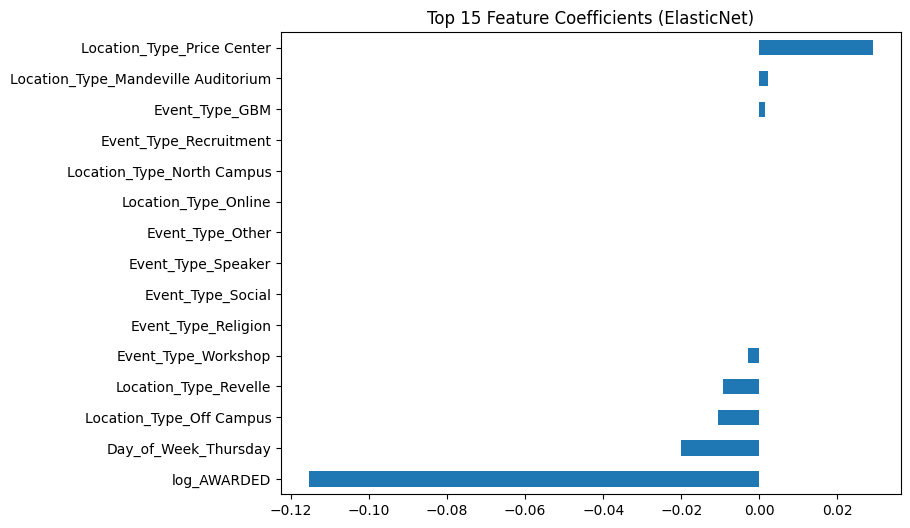

In [22]:
top_features = coef.head(15).sort_values()
top_features.plot(kind='barh', figsize=(8,6), title="Top 15 Feature Coefficients (ElasticNet)")
plt.show()

Location_Type_Price Center stands out as the strongest positive predictor of attendance.
- Events held at Price Center tend to achieve higher attendance ratios even after adjusting for other variables.

log_AWARDED has the largest negative coefficient, suggesting diminishing returns
- Increasing awarded funding does not linearly boost - attendance and may even correlate with smaller relative turnout (e.g., high-budget niche events).

### Linearity

### Homoschedacity

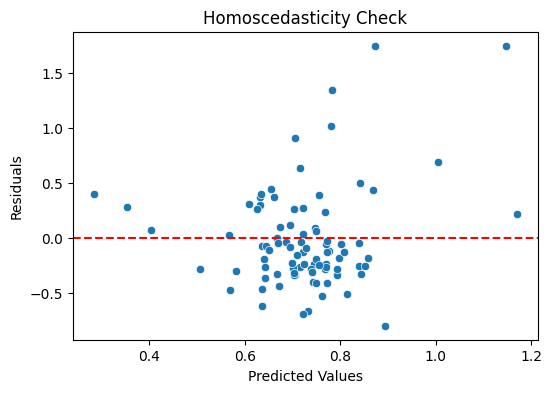

In [23]:
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Homoscedasticity Check")
plt.show()


The residuals are roughly centered around zero but show a slightly wider spread at higher predicted values, suggesting mild heteroscedasticity. This means the model’s error variance increases for events with higher predicted attendance, though the effect is not severe.

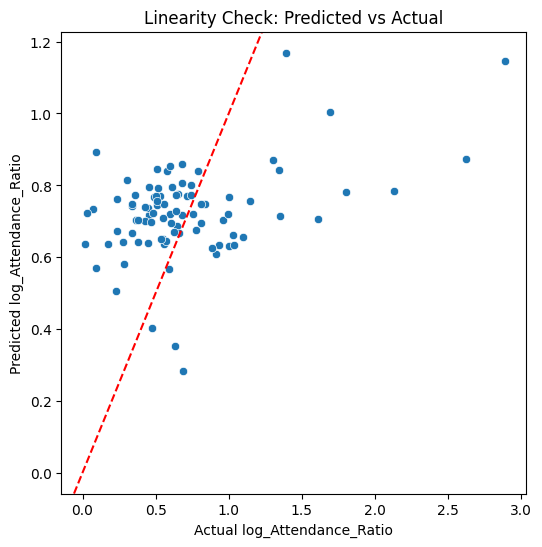

In [24]:

y_pred = elastic.predict(X_test_scaled)
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual log_Attendance_Ratio")
plt.ylabel("Predicted log_Attendance_Ratio")
plt.title("Linearity Check: Predicted vs Actual")
plt.axline((0,0), slope=1, color='red', linestyle='--')
plt.show()


The predicted values cluster below the diagonal line, indicating that the model slightly underestimates higher attendance ratios. This suggests that while the relationship is generally linear, ElasticNet may not fully capture nonlinear effects in events with unusually high attendance.

### Multicolinearity Check via Variance Inflation Factor

In [ ]:
X_vif = pd.DataFrame(X_train_scaled, columns=X.columns)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]
print(vif_data.sort_values(by="VIF", ascending=False).head(10))


                                feature        VIF
28                          log_AWARDED  43.996985
14           Location_Type_Price Center  23.051472
0                        Event_Type_GBM  13.893996
4                     Event_Type_Social  12.852692
13          Location_Type_Pepper Canyon  10.199169
20                 Location_Type_Warren  10.006139
6                   Event_Type_Workshop   5.924421
8   Location_Type_Mandeville Auditorium   5.353802
2                Event_Type_Recruitment   4.700066
5                    Event_Type_Speaker   3.356110


/home/james/Documents/VSCODEPROJECTS/COGS109_Final/venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


# !!! VIF shows significant collinearity

In [26]:
combined_encoded[['log_AWARDED', 'Location_Type_Price Center']].corr()


,log_AWARDED,Location_Type_Price Center
log_AWARDED,1.000000,0.017334
Location_Type_Price Center,0.017334,1.000000


The high VIF values here indicate strong multicollinearity among several predictors, meaning some variables (like event type and location) carry overlapping information. 

EX: events held at Price Center or certain GBM-type events often share similar funding or attendance patterns, inflating their VIF scores. While this redundancy could make coefficients unstable in ordinary least squares regression, it’s not really a concern here because ElasticNet regularization naturally mitigates multicollinearity by shrinking correlated coefficients.